In [10]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

import mplcursors
from PIL import Image
from pdf2image import convert_from_path

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

In [11]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/*/qtransform_features.parquet"))
RANDOM_STATE = 42

MONTH_ORDER = {"jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6, "jul": 7, "ago": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12}

In [12]:
if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}")

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

parquet_files = list(DATA_DIR.glob("*/*/qtransform_features.parquet"))
parquet_files.sort(key=lambda p: (int(p.parent.parent.name), MONTH_ORDER[p.parent.name]))

for file in parquet_files:
    print(f"Loading: {file}")

    df = pd.read_parquet(file)
    folder = file.parent

    image_paths = [str(folder / f"qtransform_{i:06d}.pdf")for i in range(len(df))]
    missing_images = [path for path in image_paths if not Path(path).exists()]

    if missing_images:
        raise FileNotFoundError(f"{len(missing_images)} PDF files are missing in {folder}. First missing file: {missing_images[0]}")

    df["image_path"] = image_paths
    df["source_file"] = file.name
    df["source_path"] = str(file)

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)

feature_columns = [col for col in df_all.columns if col.startswith("feature_")]
if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

print(f"Number of features: {len(feature_columns)}")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

Found 48 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jan/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/feb/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/mar/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/apr/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/may/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jun/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jul/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/ago/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/sep/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/oct/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_par

/home/rauls/Desktop/VirgoBRET/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


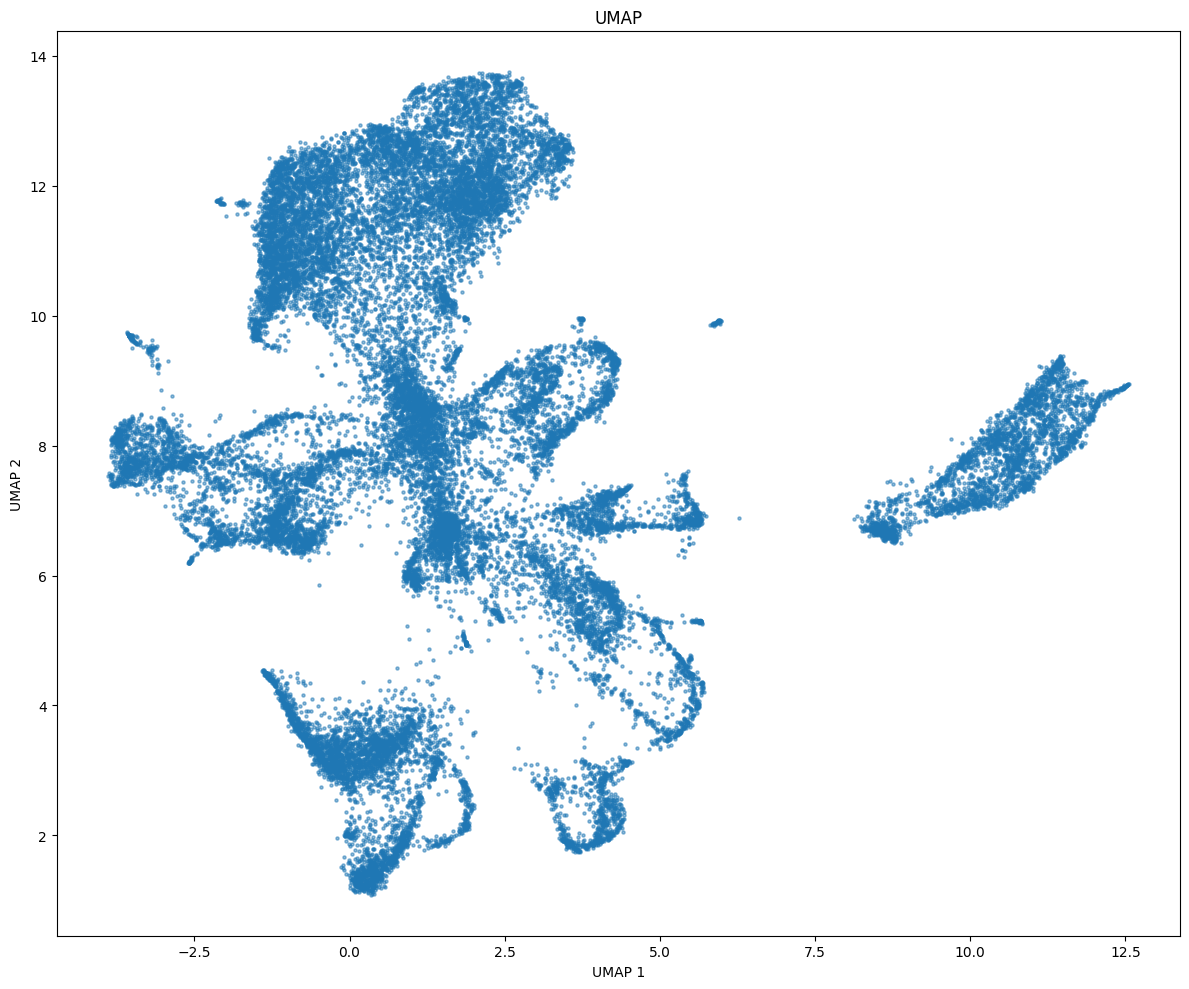

In [ ]:
X = df_all[feature_columns].to_numpy(dtype=np.float64)
X_norm = X / 40

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)
reducer = umap.UMAP(metric='manhattan', random_state=RANDOM_STATE) 

embedded = reducer.fit_transform(X_scaled)
embedded.shape

fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(embedded[:, 0], embedded[:, 1],s=5,alpha=0.5)
ax.set_title(f"UMAP")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import os
import pymupdf
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, Image, clear_output

PDF_DIR = DATA_DIR
PDF_DPI = 150
IMAGE_WIDTH = 900

df_all = df_all.copy()
df_all["_local_trigger"] = (df_all.groupby("source_path", sort=False).cumcount())

def get_pdf_path(source_path, local_trigger):
    source_dir = os.path.dirname(source_path)
    pdf_filename = (f"qtransform_{local_trigger:06d}.pdf")

    return os.path.join(source_dir, pdf_filename)

customdata = np.column_stack([np.arange(len(df_all)), df_all["source_path"].astype(str).values, df_all["_local_trigger"].values])

fig = go.FigureWidget(
    data=[go.Scatter(x=embedded[:, 0], y=embedded[:, 1],mode="markers", marker=dict(size=5, opacity=0.5), customdata=customdata,
            hovertemplate=("<b>DataFrame index:</b> %{customdata[0]}<br>" "<b>Source:</b> %{customdata[1]}<br>" "<b>Trigger:</b> %{customdata[2]}<br>"
                            "<b>UMAP 1:</b> %{x:.3f}<br>" "<b>UMAP 2:</b> %{y:.3f}" "<extra></extra>"))])

fig.update_layout(
    title=(f"UMAP"),
    xaxis_title="UMAP 1", yaxis_title="UMAP 2", width=1000, height=800, hovermode="closest")

image_output = widgets.Output(layout=widgets.Layout(width="1000px"))

pdf_cache = {}

def render_pdf(pdf_path, dpi=PDF_DPI):
    if not os.path.exists(pdf_path):
        raise FileNotFoundError(f"PDF not found:\n{pdf_path}")

    if pdf_path in pdf_cache:
        return pdf_cache[pdf_path]

    pdf = pymupdf.open(pdf_path)

    try:
        if len(pdf) == 0:
            raise ValueError("PDF contains no pages.")
        page = pdf[0]
        zoom = dpi / 72.0
        matrix = pymupdf.Matrix(zoom,zoom)
        pix = page.get_pixmap(matrix=matrix,alpha=False)
        png_bytes = pix.tobytes("png")

        pdf_cache[pdf_path] = png_bytes
        return png_bytes
    finally:
        pdf.close()


def display_qtransform(df_index,source_path,local_trigger,point_position):
    pdf_path = get_pdf_path(source_path,local_trigger)

    with image_output:
        clear_output(wait=True)
        print(f"DataFrame index : {df_index}")
        print(f"Source          : {source_path}")
        print(f"Local trigger   : {local_trigger:06d}")
        print(f"PDF             : {pdf_path}")
        print(f"t-SNE           : ({embedded[point_position, 0]:.4f}, {embedded[point_position, 1]:.4f})")
        print()

        try:
            png_bytes = render_pdf(pdf_path,dpi=PDF_DPI)
            display(Image(data=png_bytes, width=IMAGE_WIDTH))

        except FileNotFoundError as e:
            print("ERROR: PDF file was not found.")
            print(e)

        except Exception as e:
            print("ERROR while rendering PDF:")
            print(e)


def on_click(trace, points, selector):
    if not points.point_inds:
        return

    point_position = points.point_inds[0]
    df_index = int(trace.customdata[point_position][0])
    source_path = str(trace.customdata[point_position][1])
    local_trigger = int(trace.customdata[point_position][2])
    display_qtransform(df_index=df_index, source_path=source_path, local_trigger=local_trigger, point_position=point_position)

fig.data[0].on_click(on_click)
display(fig)
display(image_output)

FigureWidget({
    'data': [{'customdata': array([[0,
                                    '/home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jan/qtransform_features.parquet',
                                    0],
                                   [1,
                                    '/home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jan/qtransform_features.parquet',
                                    1],
                                   [2,
                                    '/home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/feb/qtransform_features.parquet',
                                    0],
                                   ...,
                                   [30701,
                                    '/home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/dec/qtransform_features.parquet',
                                    91],
                                   [30702,
                                    '/home/rauls/Desktop/VirgoBRET/cut_parquet_data/2025/

Output(layout=Layout(width='1000px'))